# TASK 6P SIT720

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/tysonmitchell/Downloads/bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [3]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Iin https://archive.ics.uci.edu/dataset/222/bank+marketing, it says to drop duration if trying to build a realistic predictive model as after the end of the call, y is obviously known. 

In [4]:
df = df.drop('duration', axis=1)

In [5]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

#label encode target variable  
le = preprocessing.LabelEncoder()
df['y'] = le.fit_transform(df['y'].values)

#separating x and y
y = df['y']
X = df.drop('y', axis = 1)

#Now, we will encode all categorical values using get_dummies. information for this part comes 
#from this youtube video https://www.youtube.com/watch?v=jo2ygt81nKY&t=110s
X = pd.get_dummies(X, drop_first = True) #drop first = true will create k-1 dummies and prevent collinearity

#now, we will split data into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)
print("Train shape: ",X_train.shape)
print("Test shape: ",X_test.shape)

Train shape:  (28831, 52)
Test shape:  (12357, 52)


In [6]:
print(X_train.info)  

<bound method DataFrame.info of        age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
7271    40         4    999         0           1.1          93.994   
13284   25         1    999         0           1.4          93.918   
11580   48        10    999         0           1.4          94.465   
31835   43         2    999         0          -1.8          92.893   
19551   49         1    999         0           1.4          93.444   
...    ...       ...    ...       ...           ...             ...   
12363   30         2    999         0           1.4          93.918   
5695    50         2    999         0           1.1          93.994   
8006    35         2    999         0           1.4          94.465   
17745   44        21    999         0           1.4          93.918   
17931   39         5    999         0           1.4          93.918   

       cons.conf.idx  euribor3m  nr.employed  job_blue-collar  ...  month_may  \
7271           -36.4      4.860   

/var/folders/6_/ztnkkj_13dqd8rd5ckb03gfh0000gn/T/ipykernel_59361/2027327597.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=y_train.to_frame(), x='y', palette='Set2')


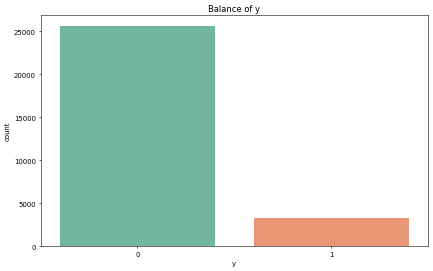

In [7]:
import seaborn as sns

plt.figure(figsize=(10,6),dpi=50)
sns.countplot(data=y_train.to_frame(), x='y', palette='Set2')
plt.title('Balance of y')
plt.show()

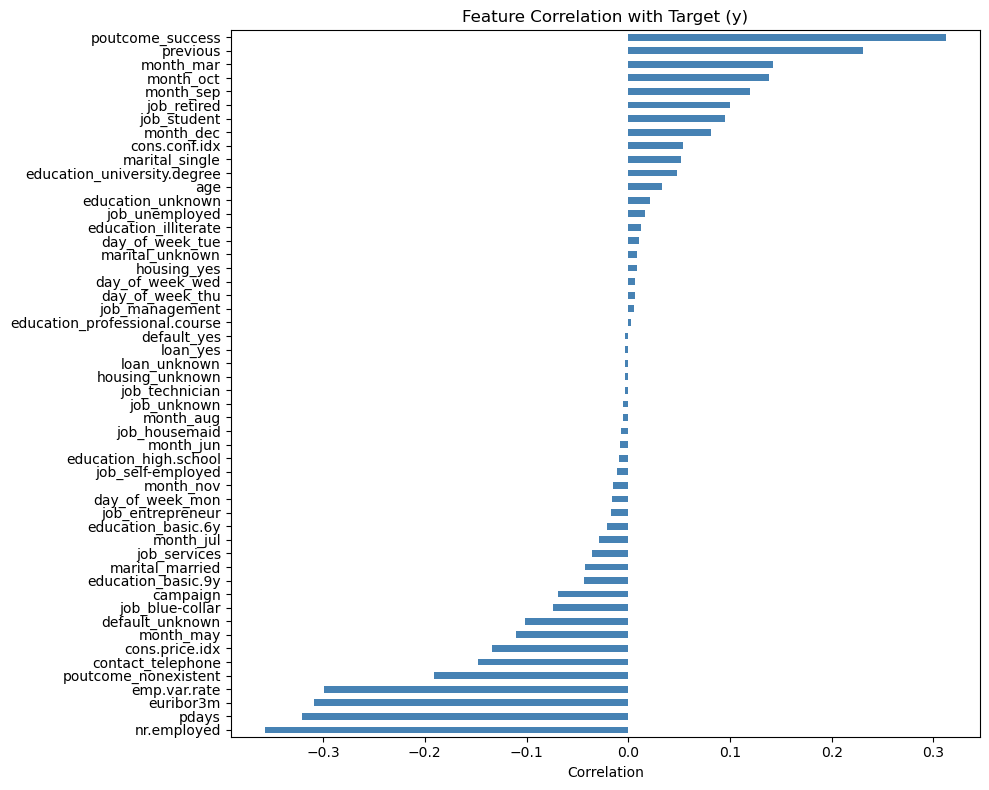

In [8]:
corr = pd.concat([X_train, y_train], axis=1).corr()['y'].drop('y').sort_values()

plt.figure(figsize=(10, 8))
corr.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Target (y)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

As there are 52 columns, i have decided to use a bar chart to show the correlation for each variable just with y. Now I will also use a heatmap to show feature correlation. 

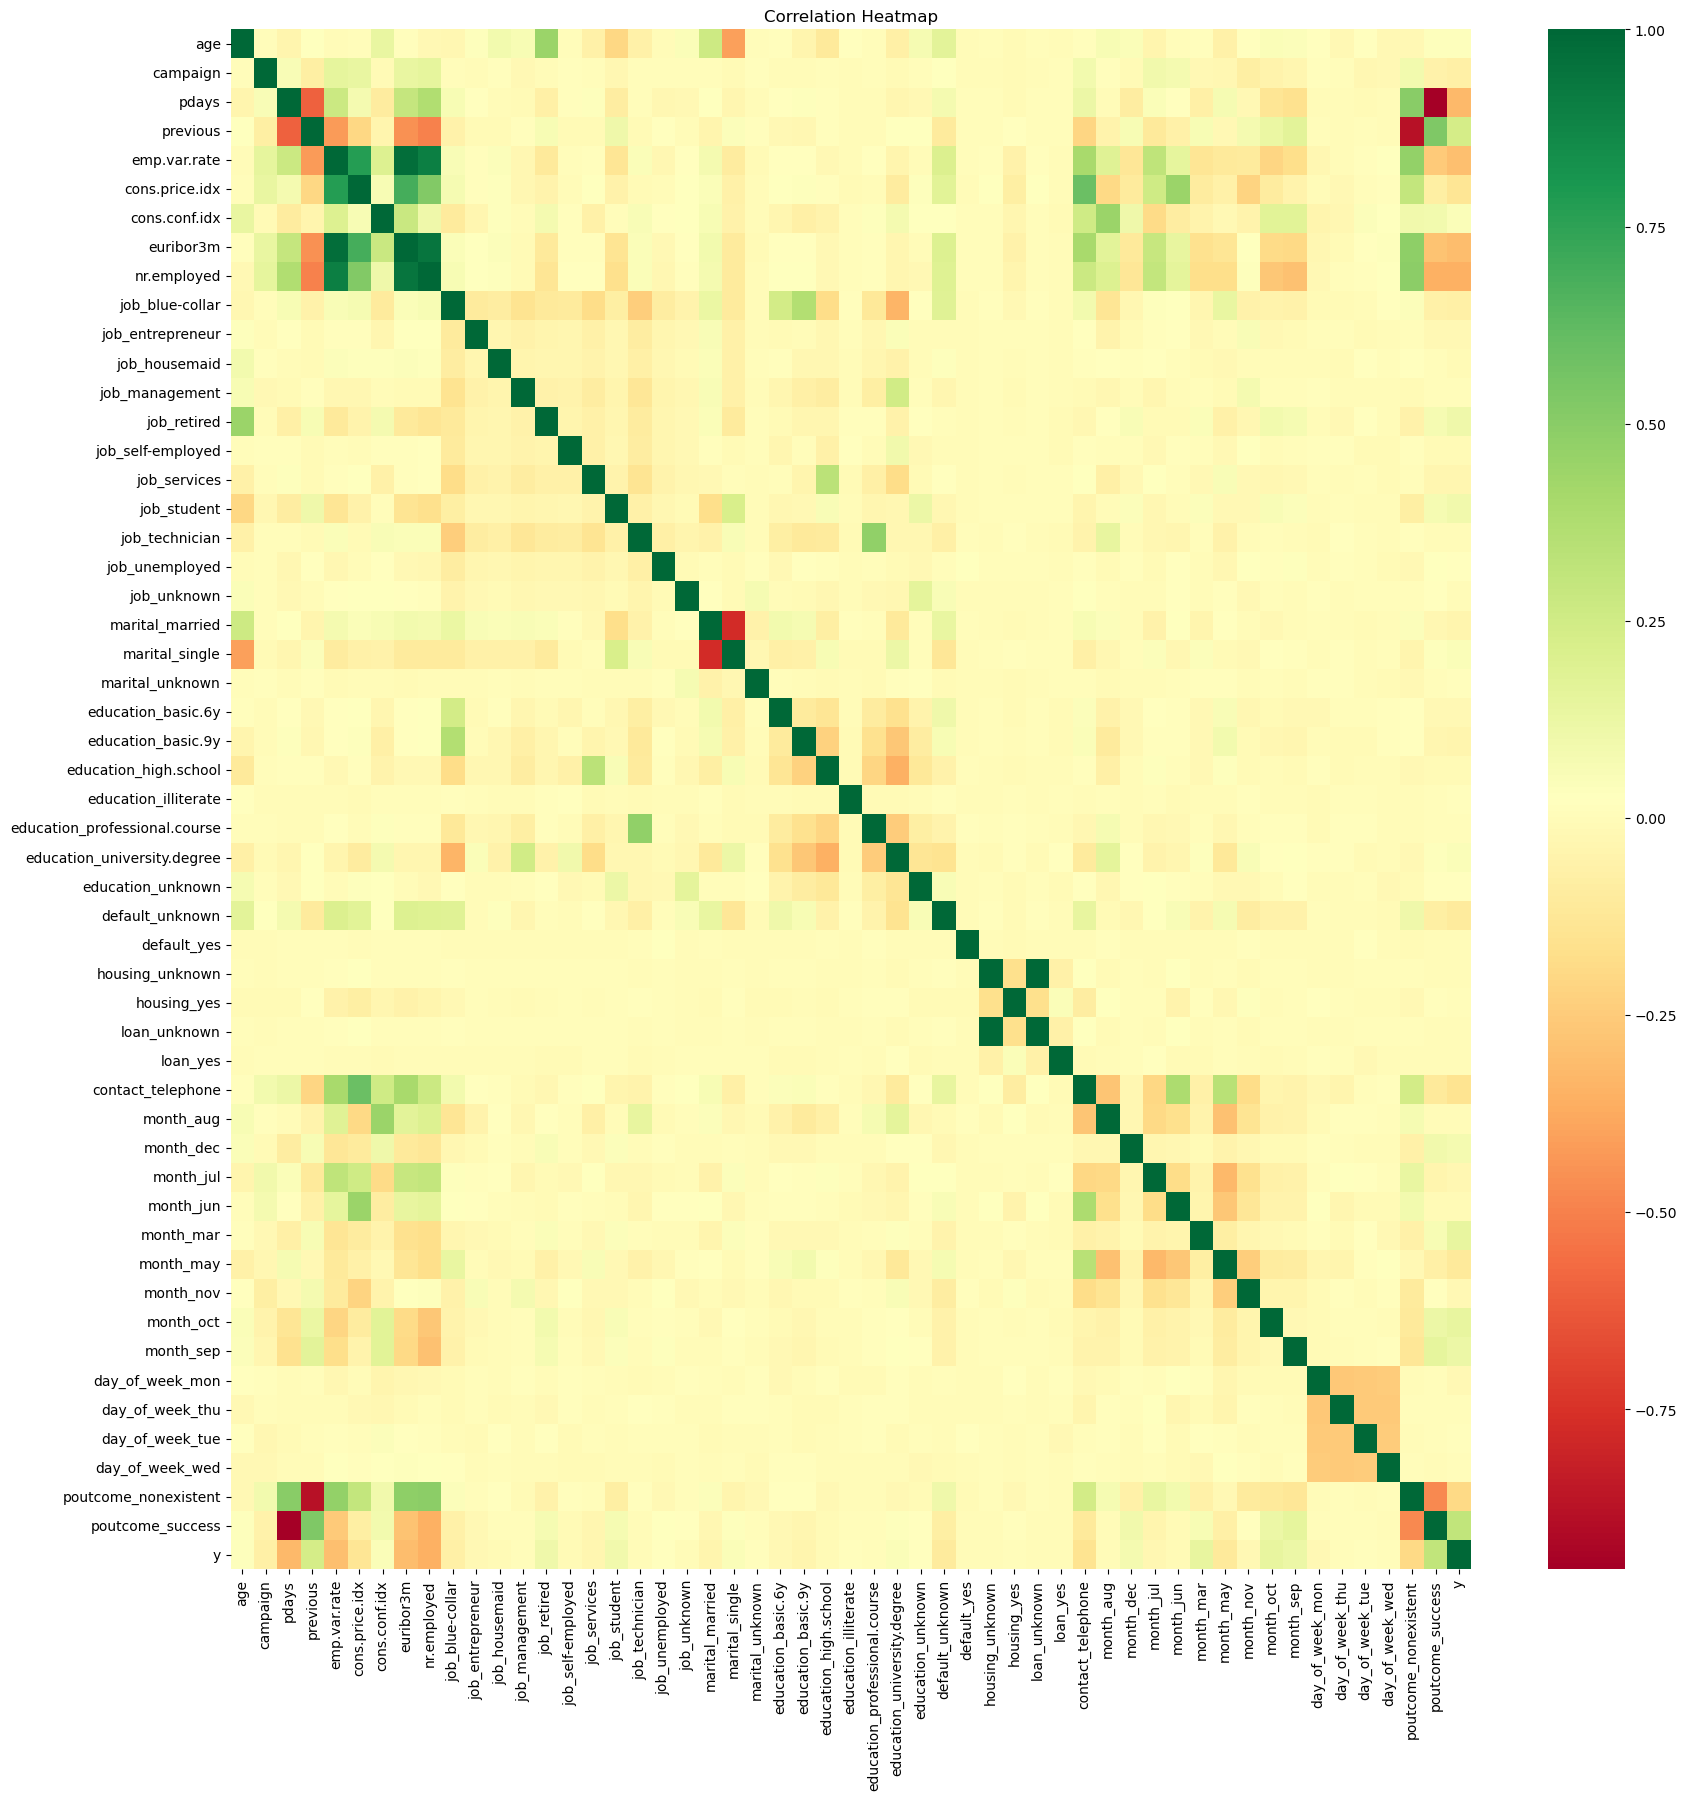

In [9]:
train_combined = pd.concat([X_train, y_train], axis=1)

corr = train_combined.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=False, cmap='RdYlGn') #annot= false otherwise it would be too crowded
plt.title('Correlation Heatmap')
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model=LogisticRegression()
model.fit(X_train, y_train)
y_predict=model.predict(X_test)

#Evaluate our model

model_acc = accuracy_score(y_test, y_predict)
print("Model Accuracy is: {}".format(model_acc))

print("Model Coeff:{}".format(np.append(model.intercept_, model.coef_)))

Model Accuracy is: 0.9000566480537348
Model Coeff:[ 3.18129616e-03  7.21938445e-03  8.61354704e-03 -1.39285416e-03
 -6.92287082e-02 -1.45758782e-01  3.83847482e-01  2.81333231e-02
 -1.95402786e-01 -6.85765555e-03 -7.73999139e-02 -4.34350906e-03
 -2.84612576e-03 -1.64440281e-04  4.07361511e-02 -5.21787208e-03
 -3.08509026e-02  3.14315418e-02  1.63422188e-02  8.64888569e-04
 -4.03916282e-03 -5.17280891e-02  6.06719777e-02  1.72407786e-03
 -7.82226430e-03 -4.22150848e-02 -1.63248482e-02  1.43199691e-03
  6.19321213e-03  6.24741530e-02  1.04427889e-02 -7.93411476e-02
 -7.65011722e-05 -2.11516883e-03 -5.57388285e-03 -2.11516883e-03
 -3.84305121e-03 -1.20453382e-01  2.43905041e-02  7.28099475e-03
  9.04631902e-02  3.58439400e-02  5.81124726e-02 -2.46956916e-01
 -2.29953115e-02  1.99133948e-02  3.21124832e-03 -4.60839824e-02
  1.46540918e-02  1.81157719e-02  2.74859240e-02  7.87793535e-02
  1.15756357e-02]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


As we can see, the model reported an accuracy of 90%. The issue with this result is that from our balance of y plot, we can see that 90% of the y values are 'no', or 0. Therefore, our model could have scored 90% if it just predicted no everytime. Hence, we will use confusion matrix and classification report for further evaluation. 

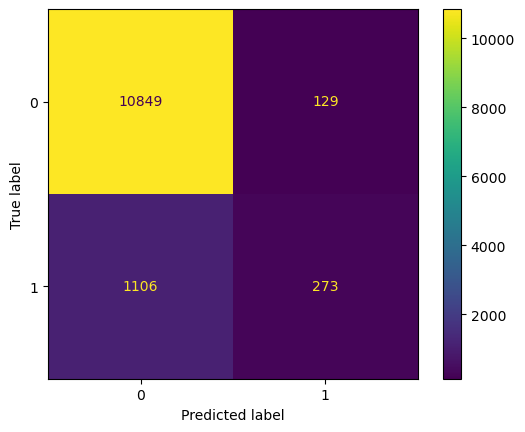

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matr = confusion_matrix(y_test, y_predict)
conf_matrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matr)
conf_matrix_display.plot()

As we can see, the model correctly predicted 10849 true negatives, 129 false positives, 1106 false negatives, and 273 true positives. This highlights a true distribution of predicted values from our test data. We will also perform a classification report to calculate te precision, recall and F1 scores. 

In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10978
           1       0.68      0.20      0.31      1379

    accuracy                           0.90     12357
   macro avg       0.79      0.59      0.63     12357
weighted avg       0.88      0.90      0.87     12357



As we can see, the model was right 91% of the time when it predicted "no", but only 68% right when it predicted "yes". The model was able to correctly identify 99% of the "no" samples, while it only predicted 20% of the actual "yes" samples. F1- score is the harmonic mean of precision and recall, with a score of 0.95 indicating the model fit the "no" samples well, while it did not fit the "yes" samples well.   

There were no hyperparameters used in the modelling. Now, we will create an optimised model and compare the performance with a standard logistic regression. 

Best C: {'C': 10}
Best F1: 0.32540568465191894


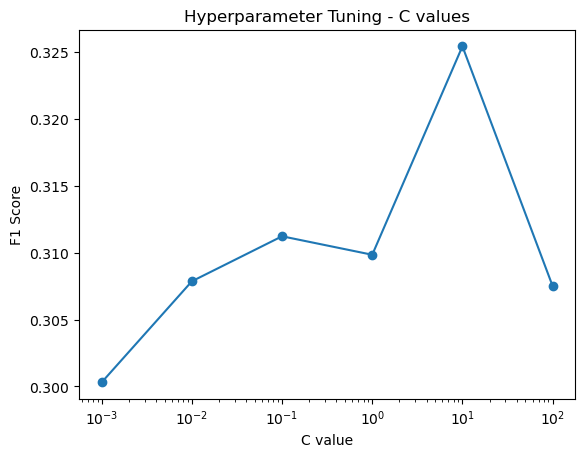

In [13]:
#We will use grid search to select the optimal C value
from sklearn.model_selection import GridSearchCV

#first, we need to define a possible range for c values 
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(LogisticRegression(penalty='l2', solver='liblinear'), #this will allow us to complete q3
                    param_grid, cv=5, scoring='f1') #as established before, judging c value based on f1 as it will be more reliable than accuracy for our data
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("Best F1:", grid.best_score_)

#we will also plot the performance of each c value
results = grid.cv_results_
plt.plot(param_grid['C'], results['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel('C value')
plt.ylabel('F1 Score')
plt.title('Hyperparameter Tuning - C values')
plt.show()

In [14]:
#Finally, let's use this optimal c value (10) and fit it to our model
best_model = grid.best_estimator_
y_predict_opt = best_model.predict(X_test)

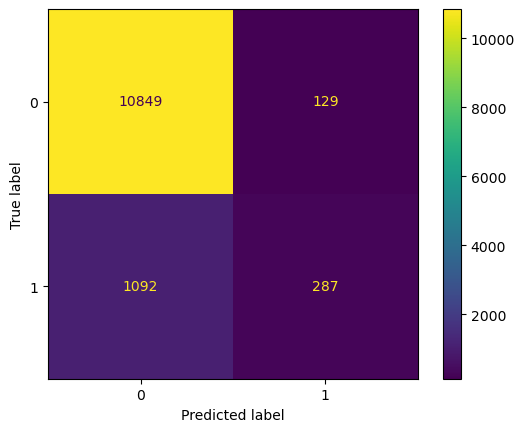

In [15]:
#let's visualise the results of the optimised model
conf_matr_opt = confusion_matrix(y_test, y_predict_opt)
conf_matrix_display2 = ConfusionMatrixDisplay(confusion_matrix=conf_matr_opt)
conf_matrix_display2.plot()

As we can see, the optimised model has 10849 true negatives and 129 false positives, which are the same as the original model. However, this model has less false negatives (1092 vs 1106) and more true positives (287 vs 273) then the original model. This indicates our optimised model was more accurate in predicting "yes" values, let's verify this with a classification report. 

In [16]:
print("Q1 Model:")
print(classification_report(y_test, y_predict))

print("Optimised Model:")
print(classification_report(y_test, y_predict_opt))

Q1 Model:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10978
           1       0.68      0.20      0.31      1379

    accuracy                           0.90     12357
   macro avg       0.79      0.59      0.63     12357
weighted avg       0.88      0.90      0.87     12357

Optimised Model:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10978
           1       0.69      0.21      0.32      1379

    accuracy                           0.90     12357
   macro avg       0.80      0.60      0.63     12357
weighted avg       0.88      0.90      0.88     12357



As we can see, the optimised model is more accurate in predicitng "yes" values. This model has a higher precision, recall and f1-score than the original model. 

In [17]:
#Now, we will create two regualrized logistic regression models using our optimal c value. 
# L1 model using best C from grid search
lr_l1 = LogisticRegression(C=grid.best_params_['C'], penalty='l1', solver='liblinear', max_iter=1000)
#max_iter=1000 as liblinear failed to converge for 100
lr_l1.fit(X_train, y_train)
y_predict_l1 = lr_l1.predict(X_test)

# L2 model using best C from grid search  
lr_l2 = LogisticRegression(C=grid.best_params_['C'], penalty='l2', solver='liblinear', max_iter=1000)
lr_l2.fit(X_train, y_train)
y_predict_l2 = lr_l2.predict(X_test)

Text(0.5, 1.0, 'L2 Regularisation')

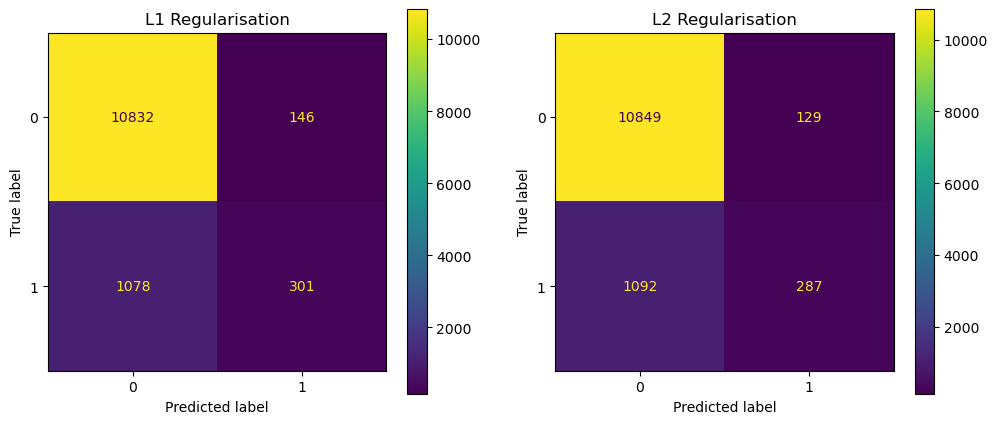

In [18]:
#Now, using our evaluation metrics from q1:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#L1 confuison matrix:
conf_matr_l1 = confusion_matrix(y_test, y_predict_l1)
conf_matrix_displayl1 = ConfusionMatrixDisplay(confusion_matrix=conf_matr_l1)
conf_matrix_displayl1.plot(ax=axes[0])
axes[0].set_title('L1 Regularisation')

#L2 confusion matrix:
conf_matr_l2 = confusion_matrix(y_test, y_predict_l2)
conf_matrix_displayl2 = ConfusionMatrixDisplay(confusion_matrix=conf_matr_l2)
conf_matrix_displayl2.plot(ax=axes[1])
axes[1].set_title('L2 Regularisation')

As we can see here, L1 regularisation lead to 10836 true negatives, while L2 regularisation lead to 10849. L1 lead to 142 false positives, while l2 only had 129. L1 had 1093 false negatives, while l2 had one less with 1092. Finally, L1 had 286 true positives, while L2 had 287. As we can see, it seems that L2 is mor eeffective at predicting "yes" and "no" scores, but only slightly. Let's verify this with a classification report. 

In [19]:
print("Q1 Model:")
print(classification_report(y_test, y_predict))

print("L1 Regularisation:")
print(classification_report(y_test, y_predict_l1))

print("L2 Regularisation:")
print(classification_report(y_test, y_predict_l2))

Q1 Model:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10978
           1       0.68      0.20      0.31      1379

    accuracy                           0.90     12357
   macro avg       0.79      0.59      0.63     12357
weighted avg       0.88      0.90      0.87     12357

L1 Regularisation:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10978
           1       0.67      0.22      0.33      1379

    accuracy                           0.90     12357
   macro avg       0.79      0.60      0.64     12357
weighted avg       0.88      0.90      0.88     12357

L2 Regularisation:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10978
           1       0.69      0.21      0.32      1379

    accuracy                           0.90     12357
   macro avg       0.80      0.60      0.63     12357
weighted avg       0.88   

As we can see, both models scored identical results for "no" scores. In terms of "yes" scores, L2 regularisation had slightly higher precision, but identical recall and f1 scores. 

In terms of the comparisons between these three models, we can deduct that the L2 regularisation model is the best model for this data set, and it can be determined through the "no" scores. As we can see, all models scored identical in terms of "no" scores. Based on our confusion matrix, we can see that they did not score completely identical, but the results were close enough to be identical for classification report results. However, there were slight differences in terms of "yes" predictions. L2 regularisation had the highest precision score for "yes" compared to L1 and the original model, indicating that the model was right 69% of the time when predicting "yes". L2 regularisation also had the highest recall score, tied with L1 regularisation, for "yes" scores. From this, we can see that while all models performed similarly, L2 regularisation is the best fit for our data. Therefore, penalising large weights through using an L2 regulariser is most suitable for this data. 

We are going to use our L2 regularisation model and find the optimal prediction probability precition threshold. 

B: ROC AUC=0.500
M: ROC AUC=0.767


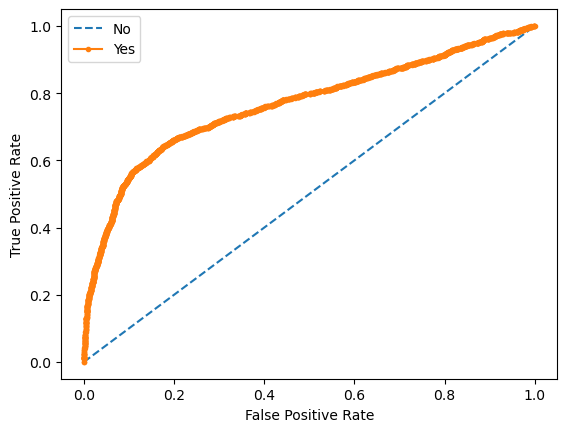

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

ns_probs = [0 for _ in range(len(y_test))]
lr_probs = model.predict_proba(X_test)

# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]

# calculate scores
ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

# summarize scores
print('B: ROC AUC=%.3f' % (ns_auc))
print('M: ROC AUC=%.3f' % (lr_auc))

# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No')
plt.plot(lr_fpr, lr_tpr, marker='.', label='Yes')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

In [21]:
thresholds_to_test = [0.2, 0.3, 0.4, 0.6, 0.7, 0.8]
for thresh in thresholds_to_test:
    y_pred_thresh = (lr_probs >= thresh).astype(int)
    print("Threshold: {}".format(thresh))
    print(classification_report(y_test, y_pred_thresh))
    print("-" * 50)

Threshold: 0.2
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     10978
           1       0.44      0.49      0.47      1379

    accuracy                           0.87     12357
   macro avg       0.69      0.71      0.70     12357
weighted avg       0.88      0.87      0.88     12357

--------------------------------------------------
Threshold: 0.3
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     10978
           1       0.48      0.40      0.44      1379

    accuracy                           0.89     12357
   macro avg       0.71      0.67      0.69     12357
weighted avg       0.88      0.89      0.88     12357

--------------------------------------------------
Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     10978
           1       0.53      0.32      0.40      1379

    accuracy                       

Based on the F1-score, we can see that a threshold of 0.2 is the best fit for this model. 0.2 reported the highest f1-score for "yes", with 0.47, and while it scored slightly lower for "no" compared to 0.4, the difference in "yes" scores (0.47 vs 0.44) overrides this. As we can see though, as threshold score increases, precision increases and recall decreases. This is to be expected, as a threshold of 0.8 would mean that the machine is very rarely predicting "yes". 

In [22]:
#For selecting an optimal k range, we will use a range of values from 1-21. 
#We are going to use the grid search method to find optimal k
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1,21)

param_grid = {'n_neighbors': k_values}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring = 'f1')# same method (f1) from q4
grid_search.fit(X_train, y_train)

#Best K:
optimal_k = grid_search.best_params_['n_neighbors']
print(f"Best K: {optimal_k}")

#training the final model with our optimal k
y_predict_knn = grid_search.best_estimator_.predict(X_test)

Best K: 7


In [23]:
#Let's compare all models 
print("Q1 Model:")
print(classification_report(y_test, y_predict))

print("Optimised Model:")
print(classification_report(y_test, y_predict_opt))

print("L1 Regularisation:")
print(classification_report(y_test, y_predict_l1))

print("L2 Regularisation:")
print(classification_report(y_test, y_predict_l2))

#Threshold = 0.2
thresh = 0.2
y_pred_thresh = (lr_probs >= thresh).astype(int)
print("Threshold = 0.2")
print(classification_report(y_test, y_pred_thresh))

print("KNN:")
print(classification_report(y_test, y_predict_knn))

Q1 Model:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10978
           1       0.68      0.20      0.31      1379

    accuracy                           0.90     12357
   macro avg       0.79      0.59      0.63     12357
weighted avg       0.88      0.90      0.87     12357

Optimised Model:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10978
           1       0.69      0.21      0.32      1379

    accuracy                           0.90     12357
   macro avg       0.80      0.60      0.63     12357
weighted avg       0.88      0.90      0.88     12357

L1 Regularisation:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10978
           1       0.67      0.22      0.33      1379

    accuracy                           0.90     12357
   macro avg       0.79      0.60      0.64     12357
weighted avg       0.88     

By comparing the f1-scores of KNN to the other models performed in this report, we can see that KNN has the second highest score for "yes", only second to threshold = 0.2. In terms of performance, we can infer that KNN is the second best fiting model, as f1-score for "yes" and "no" are both the second highest. In terms of training parameters, KNN has zero hyperparameters, and instead it can just store the entire training set compared to logistic regression. In terms of training time, while it may take longer to find the hyperparameters for logistic regression, training time itself is much faster than KNN. 

Based on the above models and findings, explore which group of
clients are more likely to subscribe a term deposit?
To find which group of clients are more likely to subscribe, we will calculate a coefficient dataframe for our best performing model (L2 regularisation with prediction = 0.2) to assess the most significant features in the dataset. 

In [24]:
# Using L2 model with best threshold of 0.2
lr_probs_l2 = lr_l2.predict_proba(X_test)[:, 1]
y_predict_best = (lr_probs_l2 >= 0.2).astype(int)

# Feature importance from L2 coefficients
w = pd.DataFrame(lr_l2.coef_, columns=X_train.columns).T
w.columns = ['Coefficient']
w = w.sort_values('Coefficient', ascending=False)
print(w)

                               Coefficient
month_mar                         0.364897
cons.price.idx                    0.348723
month_jul                         0.297050
poutcome_nonexistent              0.281681
job_retired                       0.188421
job_student                       0.140114
day_of_week_wed                   0.137270
month_jun                         0.103937
month_aug                         0.098117
day_of_week_tue                   0.068751
poutcome_success                  0.064845
marital_single                    0.058159
education_unknown                 0.045038
month_dec                         0.040515
education_university.degree       0.039027
education_basic.6y                0.035749
day_of_week_thu                   0.026847
marital_unknown                   0.016914
cons.conf.idx                     0.014287
education_illiterate              0.013135
job_technician                    0.010660
month_oct                         0.009509
age        

From this, we can see which data types were most correlated with a yes result. As we can see, these are some of the characteristics for the groups that were most likely to contact yes:

* Contacted in March/July
  
* High consumer price index

* First time being contacted

* Retired/student

* Contacted on Wednesday/Thursday

* Single

* University degree